# SQL DATA PIPELINE 

In [60]:
import yfinance as yf
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt

In [61]:
tickers = ["AAPL","GOOGL", "MSFT", "META", "XOM",
                 "CVX","WMT", "PEP", "KO", "GS", "BAC", "JPM"]

raw_data = yf.download(tickers, start="2021-01-01", end="2026-01-01", group_by="ticker")
print(raw_data)

[*********************100%***********************]  12 of 12 completed

Ticker             PEP                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2021-01-04  123.585257  124.232568  119.323124  121.281860  7486900   
2021-01-05  121.113727  122.046846  120.130145  121.643333  4126000   
2021-01-06  119.096124  120.718602  119.028870  120.155350  4843300   
2021-01-07  120.054490  120.340311  118.658993  119.768669  4473200   
2021-01-08  119.768657  121.391123  119.087726  121.206177  4312000   
...                ...         ...         ...         ...      ...   
2025-12-24  141.032916  141.229093  140.209026  140.983887  2618700   
2025-12-26  140.807334  141.180053  140.346345  141.023117  4975500   
2025-12-29  140.983891  142.268771  140.846576  141.474304  7201900   
2025-12-30  141.209469  142.484545  141.160425  141.395828  4713800   
2025-12-31  141.072150  141.268313  140.414999  140.768097  4380300   

Ticke

In [62]:
df = raw_data.stack(level = 'Ticker', future_stack=True)
print(df.head())
print(df.columns)

Price                    Open        High         Low       Close     Volume
Date       Ticker                                                           
2021-01-04 PEP     123.585257  124.232568  119.323124  121.281860    7486900
           WMT      44.762549   45.565980   44.756347   45.454308   32182200
           XOM      33.211259   33.852247   32.850702   33.251320   27764700
           AAPL    129.622529  129.709898  123.059852  125.632500  143301900
           KO       46.074761   46.380398   44.173019   44.792782   25611100
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='str', name='Price')


In [63]:
df = df.reset_index()
print(df.head())
print(df.columns)

Price       Date Ticker        Open        High         Low       Close  \
0     2021-01-04    PEP  123.585257  124.232568  119.323124  121.281860   
1     2021-01-04    WMT   44.762549   45.565980   44.756347   45.454308   
2     2021-01-04    XOM   33.211259   33.852247   32.850702   33.251320   
3     2021-01-04   AAPL  129.622529  129.709898  123.059852  125.632500   
4     2021-01-04     KO   46.074761   46.380398   44.173019   44.792782   

Price     Volume  
0        7486900  
1       32182200  
2       27764700  
3      143301900  
4       25611100  
Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str', name='Price')


In [64]:
df = df.rename(columns=str.lower)
df.columns.name = None
print(df.head())

        date ticker        open        high         low       close     volume
0 2021-01-04    PEP  123.585257  124.232568  119.323124  121.281860    7486900
1 2021-01-04    WMT   44.762549   45.565980   44.756347   45.454308   32182200
2 2021-01-04    XOM   33.211259   33.852247   32.850702   33.251320   27764700
3 2021-01-04   AAPL  129.622529  129.709898  123.059852  125.632500  143301900
4 2021-01-04     KO   46.074761   46.380398   44.173019   44.792782   25611100


In [65]:
conn = sqlite3.connect("stock_pipeline.db")
df.to_sql("prices", conn, if_exists="replace", index=False)


15060

In [ ]:
#What was AAPL's average closing price each year?
query = """
        SELECT strftime('%Y', date) AS year, 
                        AVG(close) AS avg_close
        FROM prices
        WHERE ticker = 'AAPL'
        GROUP BY year

"""

result = pd.read_sql(query, conn)
print(result)

   year   avg_close
0  2021  137.349266
1  2022  151.674639
2  2023  170.047953
3  2024  205.280350
4  2025  231.150535


In [67]:
#Which Stock had the highest trading volume 
query = """
        SELECT ticker as Ticker,
        ROUND(AVG(volume),2) AS volume
        FROM prices 
        GROUP BY ticker 
        ORDER BY volume DESC;
"""

result = pd.read_sql(query,conn)
print(result)

   Ticker       volume
0    AAPL  69815498.49
1     BAC  44180196.18
2   GOOGL  32336092.59
3    MSFT  25535292.99
4    META  21761718.01
5     WMT  20701608.76
6     XOM  19833582.15
7      KO  15252258.01
8     JPM  11143017.21
9     CVX   9437365.90
10    PEP   5701121.43
11     GS   2444358.96


In [68]:
#What was each stock's daily % return?
query = """
            SELECT ticker, date, close, prev_close,
      (close - prev_close)/prev_close * 100 AS "daily_return"
FROM (
    SELECT ticker, date, close,
           LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
    FROM prices
)
"""
result = pd.read_sql(query,conn)
print(result)

      ticker                 date       close  prev_close  daily_return
0       AAPL  2021-01-04 00:00:00  125.632500         NaN           NaN
1       AAPL  2021-01-05 00:00:00  127.185791  125.632500      1.236377
2       AAPL  2021-01-06 00:00:00  122.904533  127.185791     -3.366145
3       AAPL  2021-01-07 00:00:00  127.098434  122.904533      3.412324
4       AAPL  2021-01-08 00:00:00  128.195435  127.098434      0.863111
...      ...                  ...         ...         ...           ...
15055    XOM  2025-12-24 00:00:00  116.875412  117.071472     -0.167471
15056    XOM  2025-12-26 00:00:00  116.767570  116.875412     -0.092270
15057    XOM  2025-12-29 00:00:00  118.159645  116.767570      1.192176
15058    XOM  2025-12-30 00:00:00  118.610596  118.159645      0.381645
15059    XOM  2025-12-31 00:00:00  117.973373  118.610596     -0.537239

[15060 rows x 5 columns]


In [69]:
#Each Stock's 20-day and 50-day moving average?
query = """
SELECT ticker, date,
       AVG(close) OVER (
           PARTITION BY ticker 
           ORDER BY date 
           ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
       ) AS ma_20,
       AVG(close) OVER (
           PARTITION BY ticker 
           ORDER BY date 
           ROWS BETWEEN 50 PRECEDING AND CURRENT ROW
       ) AS ma_50
FROM prices

"""

result = pd.read_sql(query,conn)
print(result)

      ticker                 date       ma_20       ma_50
0       AAPL  2021-01-04 00:00:00  125.632500  125.632500
1       AAPL  2021-01-05 00:00:00  126.409145  126.409145
2       AAPL  2021-01-06 00:00:00  125.240941  125.240941
3       AAPL  2021-01-07 00:00:00  125.705315  125.705315
4       AAPL  2021-01-08 00:00:00  126.203339  126.203339
...      ...                  ...         ...         ...
15055    XOM  2025-12-24 00:00:00  115.001989  113.490826
15056    XOM  2025-12-26 00:00:00  115.214721  113.640637
15057    XOM  2025-12-29 00:00:00  115.440689  113.830701
15058    XOM  2025-12-30 00:00:00  115.654401  114.048092
15059    XOM  2025-12-31 00:00:00  115.897524  114.222499

[15060 rows x 4 columns]


In [70]:
#On what date did each stock hit its highest closing price in the dataset?
query  = """
SELECT ticker, date, close 
FROM (
            SELECT ticker, date, close,
           ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY close DESC, date ASC) as rn
    FROM prices
)
WHERE rn = 1;
"""

result = pd.read_sql(query,conn)
print(result)

   ticker                 date       close
0    AAPL  2025-12-02 00:00:00  285.413116
1     BAC  2025-12-24 00:00:00   55.644680
2     CVX  2023-01-26 00:00:00  161.055740
3   GOOGL  2025-11-25 00:00:00  322.808380
4      GS  2025-12-11 00:00:00  902.284058
5     JPM  2025-12-24 00:00:00  324.561249
6      KO  2025-11-28 00:00:00   71.651543
7    META  2025-08-12 00:00:00  787.419189
8    MSFT  2025-10-28 00:00:00  537.646423
9     PEP  2023-05-12 00:00:00  175.404282
10    WMT  2025-12-15 00:00:00  116.328804
11    XOM  2025-12-30 00:00:00  118.610596


In [ ]:
#Rank the 12 stocks by volatility. Riskiest to safest. 
query = """
     SELECT ticker, SQRT(AVG( (daily_return - avg_return) * (daily_return - avg_return) )) 
    AS volatility
    FROM (
        SELECT ticker, date, daily_return,
               AVG(daily_return) OVER (PARTITION BY ticker) AS avg_return
        FROM (
            SELECT ticker, date, close, prev_close,
                   (close - prev_close) / prev_close * 100 AS daily_return
            FROM (
                SELECT ticker, date, close,
                       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
                FROM prices
            )
        )
    )
    GROUP BY ticker
    ORDER BY volatility DESC

"""
result = pd.read_sql(query,conn)
print(result)

   ticker  volatility
0    META    2.733702
1   GOOGL    1.961201
2    AAPL    1.754481
3      GS    1.718886
4     BAC    1.703488
5     XOM    1.701638
6    MSFT    1.619204
7     CVX    1.588290
8     JPM    1.528550
9     WMT    1.314762
10    PEP    1.125010
11     KO    0.997110


In [ ]:
#How many days was AAPL's 20-day moving average above its 50-day moving average?
query = """
SELECT ticker, COUNT(*) AS golden_cross_days
FROM(
SELECT ticker, date,
       AVG(close) OVER (
           PARTITION BY ticker 
           ORDER BY date 
           ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
       ) AS ma_20,
       AVG(close) OVER (
           PARTITION BY ticker 
           ORDER BY date 
           ROWS BETWEEN 50 PRECEDING AND CURRENT ROW
       ) AS ma_50
FROM prices
WHERE ticker = 'AAPL'
)
WHERE ma_20 > ma_50

"""
result = pd.read_sql(query,conn)
print(result)

  ticker  golden_cross_days
0   AAPL                720


In [ ]:
#Which sector had the best average return in 2023?
stocks_data = [
    ("AAPL", "Apple Inc.", "Technology"),
    ("GOOGL", "Alphabet Inc.", "Technology"),
    ("MSFT", "Microsoft Corp.", "Technology"),
    ("META", "Meta Platforms Inc.", "Technology"),
    ("XOM", "Exxon Mobil Corp.", "Energy"),
    ("CVX", "Chevron Corp.", "Energy"),
    ("WMT", "Walmart Inc.", "Consumer Staples"),
    ("PEP", "PepsiCo Inc.", "Consumer Staples"),
    ("KO", "Coca-Cola Co.", "Consumer Staples"),
    ("GS", "Goldman Sachs Group", "Financials"),
    ("BAC", "Bank of America Corp.", "Financials"),
    ("JPM", "JPMorgan Chase & Co.", "Financials"),
]

conn.execute("""
    CREATE TABLE IF NOT EXISTS stocks (
        ticker TEXT PRIMARY KEY,
        company_name TEXT,
        sector TEXT
    )
""")

conn.executemany("INSERT OR REPLACE INTO stocks VALUES (?, ?, ?)", stocks_data)
conn.commit()

In [74]:
check = pd.read_sql("SELECT * FROM stocks", conn)
print(check)

   ticker           company_name            sector
0    AAPL             Apple Inc.        Technology
1   GOOGL          Alphabet Inc.        Technology
2    MSFT        Microsoft Corp.        Technology
3    META    Meta Platforms Inc.        Technology
4     XOM      Exxon Mobil Corp.            Energy
5     CVX          Chevron Corp.            Energy
6     WMT           Walmart Inc.  Consumer Staples
7     PEP           PepsiCo Inc.  Consumer Staples
8      KO          Coca-Cola Co.  Consumer Staples
9      GS    Goldman Sachs Group        Financials
10    BAC  Bank of America Corp.        Financials
11    JPM   JPMorgan Chase & Co.        Financials


In [ ]:
#How does Technology's volatility compare to Financials'?
query = """
            SELECT 
                 s.sector,
                AVG((dr.close - dr.prev_close) / dr.prev_close * 100) AS avg_sector_return
            FROM(
                SELECT ticker, date, close, prev_close,
                    (close - prev_close) / prev_close * 100 AS daily_return
                    FROM (
                                 SELECT ticker, date, close,
                                                LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
                                FROM prices
    ) 
                ) as dr
                JOIN stocks AS s ON dr.ticker = s.ticker
                WHERE dr.date LIKE '2023%'
                GROUP BY s.sector
                ORDER BY avg_sector_return DESC
"""
result = pd.read_sql(query,conn)
print(result)

             sector  avg_sector_return
0        Technology           0.257032
1        Financials           0.073022
2  Consumer Staples           0.009981
3            Energy          -0.030711


In [76]:
query = """
     SELECT s.sector,
                     SQRT(AVG( (daily_return - avg_return) * (daily_return - avg_return) )) 
    AS volatility
    FROM (
        SELECT ticker, date, daily_return,
               AVG(daily_return) OVER (PARTITION BY ticker) AS avg_return
        FROM (
            SELECT ticker, date, close, prev_close,
                   (close - prev_close) / prev_close * 100 AS daily_return
            FROM (
                SELECT ticker, date, close,
                       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
                FROM prices
            )
        )
    ) AS dr
    JOIN stocks AS s ON dr.ticker = s.ticker
    WHERE s.sector IN ('Technology', 'Financials')
    GROUP BY s.sector
    ORDER BY volatility DESC

"""
result = pd.read_sql(query,conn)
print(result)

       sector  volatility
0  Technology    2.062733
1  Financials    1.652564


VISUALIZATION

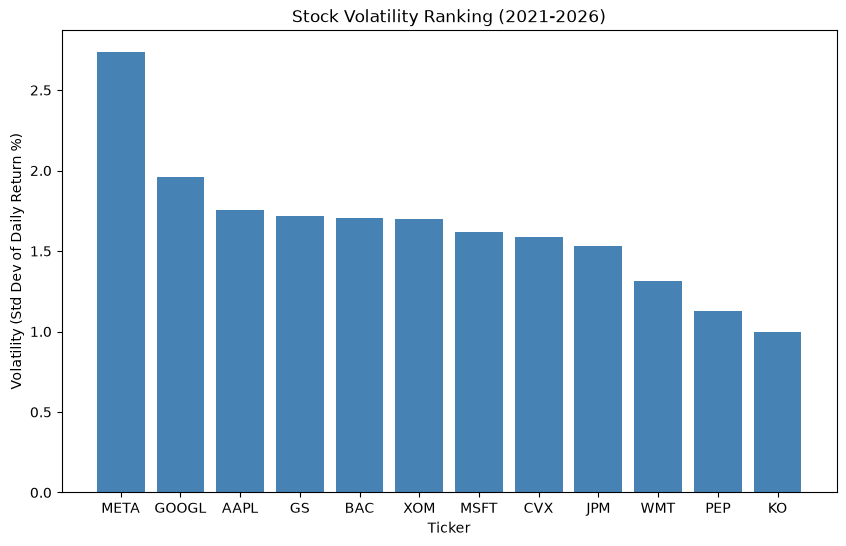

In [ ]:
#Visualizaion for Stock Volatility ranking. 
result = pd.read_sql("""
    SELECT ticker, SQRT(AVG( (daily_return - avg_return) * (daily_return - avg_return) )) 
    AS volatility
    FROM (
        SELECT ticker, date, daily_return,
               AVG(daily_return) OVER (PARTITION BY ticker) AS avg_return
        FROM (
            SELECT ticker, date, close, prev_close,
                   (close - prev_close) / prev_close * 100 AS daily_return
            FROM (
                SELECT ticker, date, close,
                       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
                FROM prices
            )
        )
    )
    GROUP BY ticker
    ORDER BY volatility DESC
""", conn)

plt.figure(figsize=(10, 6))
plt.bar(result['ticker'], result['volatility'], color='steelblue')
plt.xlabel('Ticker')
plt.ylabel('Volatility (Std Dev of Daily Return %)')
plt.title('Stock Volatility Ranking (2021-2026)')
plt.show()